In [9]:
#1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

from tensorflow.keras.utils import to_categorical

In [10]:
#2. Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [11]:
#3. Check shapes
print("Training shape: ", X_train.shape)
print("Testing Shape: ", X_test.shape)

Training shape:  (60000, 28, 28)
Testing Shape:  (10000, 28, 28)


In [12]:
#4. Normaliza Images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [13]:
#5. Reshape Images
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [14]:
#6. One hot encoding on categorical values
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [15]:
#7. Build CNN Model

model = Sequential()

#First Convolution Layer
model.add(
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))
)

#First Pooling Layer
model.add(MaxPooling2D(2,2))

#Second Convolution Layer
model.add(
    Conv2D(64, (3,3), activation='relu')
)

#Second Pooling Layer
model.add(MaxPooling2D(2,2))

#Flatten layer
model.add(Flatten())

#Dense Layer
model.add(Dense(128, activation='relu'))

#Dropout to prevent overfitting - Randomly sets 50% of neurons to 0 during training
model.add(Dropout(0.5))

#Output layer
model.add(Dense(10, activation='softmax'))

In [16]:
#8. Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#9. Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.7685 - loss: 0.6440 - val_accuracy: 0.8624 - val_loss: 0.3863
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8499 - loss: 0.4190 - val_accuracy: 0.8773 - val_loss: 0.3356
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8683 - loss: 0.3685 - val_accuracy: 0.8849 - val_loss: 0.3094
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8804 - loss: 0.3352 - val_accuracy: 0.8938 - val_loss: 0.2908
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8868 - loss: 0.3115 - val_accuracy: 0.8973 - val_loss: 0.2782
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8929 - loss: 0.2895 - val_accuracy: 0.8974 - val_loss: 0.2814
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9001 - loss: 0.2765 - val_accuracy: 0.9015 - val_loss: 0.2681
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9053 - loss: 0.2592 - 

In [18]:
#10. Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy: ", accuracy)
print("Loss: ", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8964 - loss: 0.2866
Accuracy:  0.896399974822998
Loss:  0.2866285443305969


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Classes: 



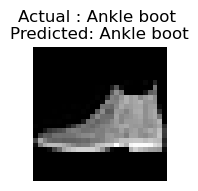

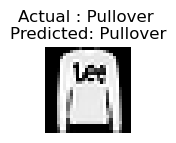

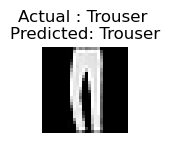

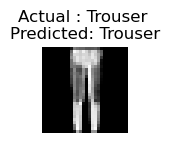

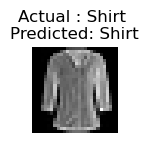

In [24]:
#11. Prediction
predictions = model.predict(X_test[:5])

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Predicted Classes: \n")

plt.figure(figsize=(10,4))

#Show images output predicted vs actual
for i in range(5):
    plt.subplot(1,5,i+1)
    #Predicted Label
    predicted_class = np.argmax(predictions[i])
    #print("Image ",i+1,": ", class_names[predicted_class])
    #Actual Label
    actual_class = np.argmax(y_test[i])

    #Show image
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(f"Actual : {class_names[actual_class]} \n"
              f"Predicted: {class_names[predicted_class]}")

    plt.axis("off")

    plt.show()

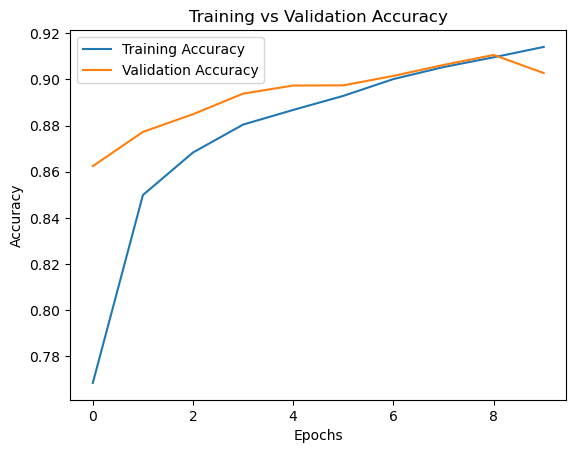

In [25]:
# Step 12: Plot Accuracy Graph

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()